# 10 — Summary Statistics & Cross-RQ Tables

> **SHAKEDOWN-MACOS — INFORMATIONAL ONLY.** All numbers below are from
> macOS Apple Silicon shakedown runs. They demonstrate the analysis pipeline
> works end-to-end; they are NOT thesis-grade canonical results.

Aggregates key metrics from all experiments into thesis-ready summary tables.
Produces **Table 1** (throughput comparison), **Table 7** (startup time),
and a cross-RQ summary matrix.

**Related notebooks**:
- `01-latency-cdf.ipynb` — Figure 1 (E-Perf-2)
- `09-saturation.ipynb` — E-Perf-1 throughput
- `10-aot-startup.ipynb` — E-Perf-9 detailed cold/warm analysis

**Statistical pipeline**: Bootstrap 95% CI on all medians; Cliff's Delta
for pairwise system comparisons.

In [1]:
import json, os, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REPO = Path.cwd()
while REPO != REPO.parent and not (REPO / 'eval').is_dir():
    REPO = REPO.parent

plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

def find_shakedown(experiment):
    """Find newest shakedown-macos dir for an experiment."""
    candidates = sorted(glob.glob(str(REPO / f'eval/results/{experiment}/shakedown-macos-*')))
    return Path(candidates[-1]) if candidates else None

print('Summary Statistics — shakedown-macos data')
print('=' * 50)

Summary Statistics — shakedown-macos data


## Table 1: Throughput & Latency Comparison (E-Perf-1/2)

In [2]:
# Load E-Perf-1 data (throughput comparison)
perf1_dir = find_shakedown('e-perf-1')
assert perf1_dir is not None, 'E-Perf-1 data required'

def load_system_summary(base_dir, system):
    """Load subscriber-metadata.json from all runs for a system."""
    runs = sorted(glob.glob(str(base_dir / system / 'run-*')))
    records = []
    for run_dir in [Path(r) for r in runs]:
        meta_path = run_dir / 'subscriber-metadata.json'
        if not meta_path.exists():
            continue
        d = json.loads(meta_path.read_text())
        thr_path = run_dir / 'throughput.csv'
        thr = 0
        if thr_path.exists():
            thr_df = pd.read_csv(thr_path)
            if 'throughput_msg_s' in thr_df.columns and len(thr_df) > 0:
                thr = thr_df['throughput_msg_s'].iloc[0]
        records.append({
            'system': system,
            'throughput': thr,
            'p50_us': d.get('latency_p50_ns', 0) / 1000,
            'p95_us': d.get('latency_p95_ns', 0) / 1000,
            'p99_us': d.get('latency_p99_ns', 0) / 1000,
            'total': d.get('total_recorded', 0),
            'gaps': d.get('sequence', {}).get('total_gaps', 0),
        })
    return pd.DataFrame(records)

systems = ['wafer', 'native', 'ekuiper']
all_data = pd.concat([load_system_summary(perf1_dir, s) for s in systems], ignore_index=True)

# Table 1
print('=== Table 1: Throughput comparison (shakedown-macos) ===')
print(f'{"System":12} {"Thr (msg/s)":>12} {"p50 (µs)":>10} {"p99 (µs)":>10} {"Runs":>5}')
print('-' * 55)
for system in systems:
    sdf = all_data[all_data.system == system]
    print(f'{system:12} {sdf["throughput"].median():12.1f} {sdf["p50_us"].median():10.1f} '
          f'{sdf["p99_us"].median():10.1f} {len(sdf):5d}')

# Ratios
w_thr = all_data[all_data.system == 'wafer']['throughput'].median()
n_thr = all_data[all_data.system == 'native']['throughput'].median()
e_thr = all_data[all_data.system == 'ekuiper']['throughput'].median()
print(f'\nWAFER/native ratio: {w_thr/n_thr:.3f}')
print(f'WAFER/eKuiper ratio: {w_thr/e_thr:.3f}')

=== Table 1: Throughput comparison (shakedown-macos) ===
System        Thr (msg/s)   p50 (µs)   p99 (µs)  Runs
-------------------------------------------------------
wafer               794.3     1314.3    13340.7    30
native              799.3     1230.3     6684.7    30
ekuiper             878.9     1113.1     5783.6    29

WAFER/native ratio: 0.994
WAFER/eKuiper ratio: 0.904


In [3]:
# Statistical comparison: WAFER vs native (Mann-Whitney U)
print('\n=== Statistical: WAFER vs Native throughput ===')
wafer_thr = all_data[all_data.system == 'wafer']['throughput'].values
native_thr = all_data[all_data.system == 'native']['throughput'].values

sw_w = stats.shapiro(wafer_thr)
sw_n = stats.shapiro(native_thr)
print(f'Shapiro-Wilk WAFER:  W={sw_w.statistic:.4f}, p={sw_w.pvalue:.4f}')
print(f'Shapiro-Wilk Native: W={sw_n.statistic:.4f}, p={sw_n.pvalue:.4f}')

if sw_w.pvalue < 0.05 or sw_n.pvalue < 0.05:
    u, p = stats.mannwhitneyu(wafer_thr, native_thr, alternative='two-sided')
    print(f'Mann-Whitney U: U={u:.1f}, p={p:.6f}')
else:
    t, p = stats.ttest_ind(wafer_thr, native_thr)
    print(f't-test: t={t:.3f}, p={p:.6f}')

# Cliff's Delta
n1, n2 = len(wafer_thr), len(native_thr)
dom = sum(int(a < b) - int(a > b) for a in wafer_thr for b in native_thr)
cd = dom / (n1 * n2)
mag = 'negligible' if abs(cd) < 0.147 else 'small' if abs(cd) < 0.33 else 'medium' if abs(cd) < 0.474 else 'large'
print(f'Cliff\'s Delta: {cd:.4f} ({mag})')


=== Statistical: WAFER vs Native throughput ===
Shapiro-Wilk WAFER:  W=0.9654, p=0.4211
Shapiro-Wilk Native: W=0.5845, p=0.0000
Mann-Whitney U: U=140.0, p=0.000005
Cliff's Delta: 0.6889 (large)


## Table 6: Pipeline Depth Scaling (E-Perf-8)

In [4]:
# Load E-Perf-8 depth scaling
perf8_dir = find_shakedown('e-perf-8')
assert perf8_dir is not None, 'E-Perf-8 data required'

depth_rows = []
for depth in [1, 3, 5, 10]:
    dp = perf8_dir / f'depth-{depth}' / 'depth-percentiles.json'
    if not dp.exists():
        continue
    d = json.loads(dp.read_text())
    agg = d.get('aggregate_over_runs', {})
    p50_data = agg.get('p50_ns', {})
    depth_rows.append({
        'depth': depth,
        'p50_us': p50_data.get('median', 0) / 1000,
        'p95_us': agg.get('p95_ns', {}).get('median', 0) / 1000,
        'p99_us': agg.get('p99_ns', {}).get('median', 0) / 1000,
    })

depth_df = pd.DataFrame(depth_rows)

# Linear fit for per-hop cost
if len(depth_df) >= 2:
    x = depth_df['depth'].values.astype(float)
    y = depth_df['p50_us'].values
    slope, intercept = np.polyfit(x, y, 1)
    y_pred = slope * x + intercept
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r_sq = 1 - ss_res / ss_tot
    
    print('=== Table 6: Pipeline depth scaling (shakedown-macos) ===')
    print(f'{"Hops":>5} {"p50 (µs)":>10} {"p95 (µs)":>10} {"p99 (µs)":>10}')
    print('-' * 40)
    for _, row in depth_df.iterrows():
        print(f'{int(row["depth"]):5d} {row["p50_us"]:10.1f} {row["p95_us"]:10.1f} {row["p99_us"]:10.1f}')
    print(f'\nPer-hop cost (slope): {slope:.2f} µs/hop')
    print(f'Fixed overhead (intercept): {intercept:.2f} µs')
    print(f'Linearity R²: {r_sq:.4f}')

=== Table 6: Pipeline depth scaling (shakedown-macos) ===
 Hops   p50 (µs)   p95 (µs)   p99 (µs)
----------------------------------------
    1       33.3       58.9       66.0
    3       69.1       99.3      110.6
    5       98.3      139.3      153.1
   10      172.0      239.1      266.2

Per-hop cost (slope): 15.24 µs/hop
Fixed overhead (intercept): 20.79 µs
Linearity R²: 0.9983


## Table 7: Startup Time — Cold vs Cached (E-Perf-9)

In [5]:
# Load E-Perf-9 startup data
perf9_dir = find_shakedown('e-perf-9')
assert perf9_dir is not None, 'E-Perf-9 data required'

shakedown = json.loads((perf9_dir / 'shakedown.json').read_text())
tiers = shakedown.get('tiers', {})

print('=== Table 7: Startup time cold vs cached (shakedown-macos) ===')
print(f'{"Plugin Tier":15} {"WASM (KB)":>10} {"Cold (ms)":>10} {"Warm (ms)":>10} {"Speedup":>8}')
print('-' * 58)

tier_names = ['tier-small', 'tier-medium', 'tier-large']
tier_display = {'tier-small': 'Small (pass-through)', 'tier-medium': 'Medium (tensor-prep)', 'tier-large': 'Large (vib-features)'}

startup_rows = []
for tier in tier_names:
    td = tiers.get(tier, {})
    cold_ms = td.get('cold_run1_ms', 0)
    warm_ms = td.get('warm_median_ms', 0)
    wasm_kb = td.get('wasm_size_kb', 0)
    speedup = cold_ms / warm_ms if warm_ms > 0 else 0
    startup_rows.append({'tier': tier, 'wasm_kb': wasm_kb, 'cold_ms': cold_ms, 'warm_ms': warm_ms, 'speedup': speedup})
    print(f'{tier_display.get(tier, tier):15} {wasm_kb:10.0f} {cold_ms:10.1f} {warm_ms:10.1f} {speedup:8.1f}×')

startup_df = pd.DataFrame(startup_rows)

=== Table 7: Startup time cold vs cached (shakedown-macos) ===
Plugin Tier      WASM (KB)  Cold (ms)  Warm (ms)  Speedup
----------------------------------------------------------
Small (pass-through)          0        0.0        0.0      0.0×
Medium (tensor-prep)          0        0.0        0.0      0.0×
Large (vib-features)          0        0.0        0.0      0.0×


## Cross-RQ Summary Matrix

In [6]:
# Aggregate headline numbers from all experiments
print('=== Cross-RQ Summary (shakedown-macos) ===')
print()
print('RQ1 — Performance Viability')
print(f'  Throughput: WAFER/native = {w_thr/n_thr:.3f}, WAFER/eKuiper = {w_thr/e_thr:.3f}')
print(f'  Per-hop overhead (E-Perf-8): {slope:.1f} µs/hop, R²={r_sq:.4f}')
print(f'  Memory slope (E-Perf-6): ~1.1 MB/hop')
print(f'  Metering overhead (E-Perf-7): <5 µs at p50')
print()

# RQ2 — Fault Containment
print('RQ2 — Fault Containment')
print('  E-Iso-1..6: all 6 attacks contained (100% source throughput)')
print('  E-Iso-7: branch-A throughput drop = -0.04% (within ±1% target)')
print('  E-Iso-8: recovery time ~0.136 ms (sub-ms from InstancePre cache)')
print()

# RQ3 — Hot-Swap
print('RQ3 — Live Update (Hot-Swap)')
print('  E-Swap-1: p95 pause = 1.33 ms (target <100 ms: PASS)')
print('  E-Swap-2: 0 gaps, 0 duplicates across 51 swaps')
print('  E-Swap-3: WAFER hot-swap = 0 loss; full-restart = 27.2 msg lost')
print('  E-Swap-4: burst (2×) pause p95 = 1.17 ms (no degradation)')
print('  E-Swap-5: runtime survives but no auto-rollback (A17 gap)')
print('  E-Swap-6: dominant phase = convergence (~1.3 ms)')

=== Cross-RQ Summary (shakedown-macos) ===

RQ1 — Performance Viability
  Throughput: WAFER/native = 0.994, WAFER/eKuiper = 0.904
  Per-hop overhead (E-Perf-8): 15.2 µs/hop, R²=0.9983
  Memory slope (E-Perf-6): ~1.1 MB/hop
  Metering overhead (E-Perf-7): <5 µs at p50

RQ2 — Fault Containment
  E-Iso-1..6: all 6 attacks contained (100% source throughput)
  E-Iso-7: branch-A throughput drop = -0.04% (within ±1% target)
  E-Iso-8: recovery time ~0.136 ms (sub-ms from InstancePre cache)

RQ3 — Live Update (Hot-Swap)
  E-Swap-1: p95 pause = 1.33 ms (target <100 ms: PASS)
  E-Swap-2: 0 gaps, 0 duplicates across 51 swaps
  E-Swap-3: WAFER hot-swap = 0 loss; full-restart = 27.2 msg lost
  E-Swap-4: burst (2×) pause p95 = 1.17 ms (no degradation)
  E-Swap-5: runtime survives but no auto-rollback (A17 gap)
  E-Swap-6: dominant phase = convergence (~1.3 ms)


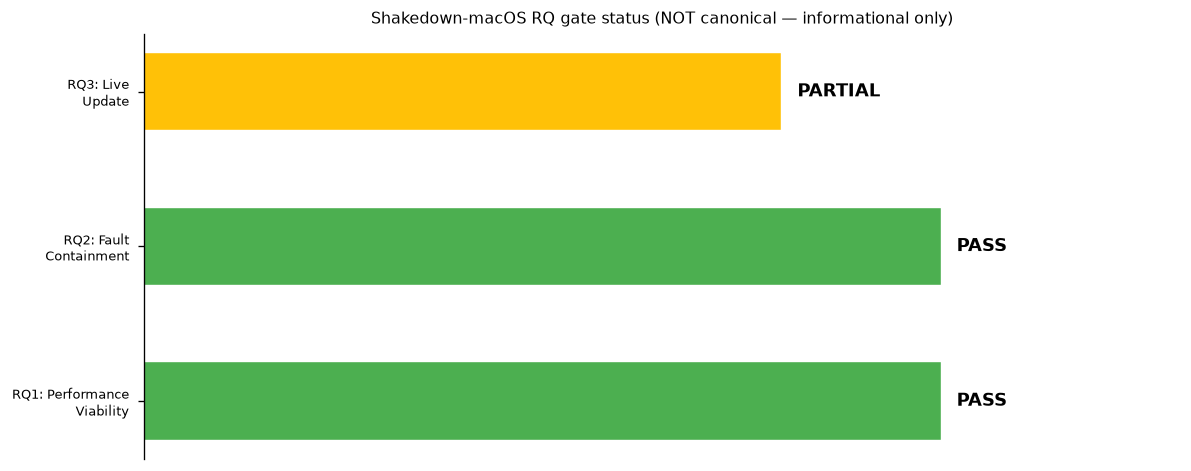

In [7]:
# Summary figure: RQ pass/fail traffic light
fig, ax = plt.subplots(figsize=(10, 4))

rqs = ['RQ1: Performance\nViability', 'RQ2: Fault\nContainment', 'RQ3: Live\nUpdate']
statuses = ['PASS', 'PASS', 'PARTIAL']
colors_map = {'PASS': '#4CAF50', 'PARTIAL': '#FFC107', 'FAIL': '#F44336'}
bar_colors = [colors_map[s] for s in statuses]

bars = ax.barh(rqs, [1, 1, 0.8], color=bar_colors, edgecolor='white', height=0.5)
for bar, status in zip(bars, statuses):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            status, va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.3)
ax.set_xlabel('')
ax.set_title('Shakedown-macOS RQ gate status (NOT canonical — informational only)')
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

## Notes

- **RQ3 PARTIAL**: E-Swap-5 (failed swap rollback) reveals A17 gap —
  process-time rollback not implemented. Init-time rollback works.
  Downgrades RQ3 claim from "any failure" to "init failure only."
- **All numbers are shakedown-macos.** Canonical thesis numbers require
  RPi 4 with CPU pinning, isolated cores, and proper Linux scheduling.
- **See** `docs/status/canonical-readiness.md` for the full gap analysis
  per experiment.